<a href="https://colab.research.google.com/github/PalQuisp/Sis420-int/blob/main/lab1_reg_lin_steam_games.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio: Regresión Lineal con Steam Games Dataset V2

**Objetivo:** adaptar el laboratorio de regresión lineal al dataset de Steam Games Dataset V2.

En este ejercicio se utilizará:
- **Variable independiente (X):** `positive` → cantidad de reseñas positivas.
- **Variable objetivo (y):** `negative` → cantidad de reseñas negativas.

La finalidad es aplicar normalización, función de costo y descenso por el gradiente para encontrar los parámetros de una regresión lineal.

In [1]:
# Importación de librerías
import numpy as np
import pandas as pd
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

# Para reproducibilidad
np.random.seed(42)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Carga de datos para procesamiento

In [2]:
# El archivo debe estar en la misma carpeta que este notebook.
# Dataset: Steam Games Dataset V2
data = pd.read_csv('/content/drive/MyDrive/machine learning/laboratorio/regsimple.csv', delimiter=',')
#data = pd.read_csv('extended_steam_games.csv')

# Utilizamos las primeras 10.000 filas para mantener el ejercicio manejable
data = data.head(10000)

# Revisamos las columnas disponibles
print("Dimensiones:", data.shape)
print("\nColumnas:")
print(data.columns.tolist())

# Característica (X) y variable objetivo (y)
x = data['positive'].values.astype(float)
y = data['negative'].values.astype(float)

# Eliminar filas con datos faltantes
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

# Número correcto de ejemplos después de limpiar los datos
m = y.size

print("\nPrimeros valores de X (reseñas positivas):")
print(x[:10])

print("\nPrimeros valores de y (reseñas negativas):")
print(y[:10])

print("\nNúmero de ejemplos:", m)

Dimensiones: (10000, 28)

Columnas:
['appid', 'name', 'developer', 'publisher', 'positive', 'negative', 'owners', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu', 'release_date', 'required_age', 'is_free', 'short_description', 'supported_languages', 'platforms_windows', 'platforms_mac', 'platforms_linux', 'metacritic_score', 'recommendations', 'achievements', 'genres', 'categories']

Primeros valores de X (reseñas positivas):
[7642084.  668053. 1520457.  358266. 1044264.  419594.  196798. 1111720.
 1739980.  940221.]

Primeros valores de y (reseñas negativas):
[1173003.  326926. 1037487.   22443.  117208.  294520.   90080.   38378.
  250576.   23762.]

Número de ejemplos: 10000


## Gráfica de los datos

In [3]:
def plotData(x, y):
    # Grafica los puntos X e y en una figura nueva.
    pyplot.figure(figsize=(8, 5))
    pyplot.plot(x, y, 'ro', ms=4, mec='k')
    pyplot.ylabel('Reseñas negativas')
    pyplot.xlabel('Reseñas positivas')
    pyplot.title('Reseñas positivas vs. reseñas negativas')
    pyplot.grid(True, alpha=0.3)

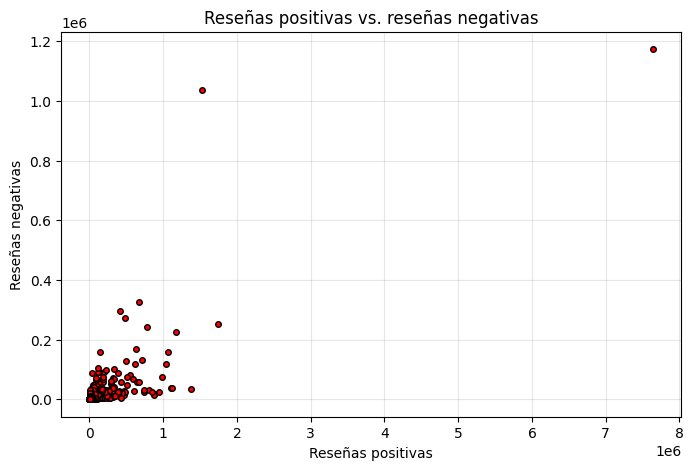

In [4]:
plotData(x, y)

## Normalización de la variable X

Se normaliza X para que los valores grandes del dataset no dificulten el descenso por el gradiente.

La fórmula utilizada es:

\[
x_{norm} = \frac{x - \mu}{\sigma}
\]

donde:
- \(\mu\) = media de X.
- \(\sigma\) = desviación estándar de X.

Media original: 12141.9412
Desviación estándar original: 95364.49804210132

X normalizada:
[80.00820238  6.87793752 15.81631624  3.62948546 10.82291712  4.27257593
  1.93631868 11.53026631 18.11825254  9.73191364]


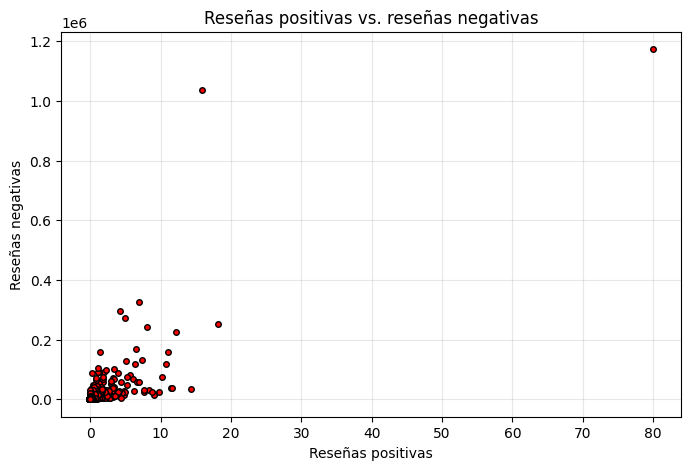

In [5]:
x_mean = np.mean(x)
x_std = np.std(x)

x = (x - x_mean) / x_std

print("Media original:", x_mean)
print("Desviación estándar original:", x_std)
print("\nX normalizada:")
print(x[:10])

plotData(x, y)

# Implementación del descenso por el gradiente

In [6]:
# Agregar la columna de unos para representar theta_0
x = np.c_[np.ones(x.shape[0]), x]

print(x[:10])
print("Forma de X:", x.shape)

[[ 1.         80.00820238]
 [ 1.          6.87793752]
 [ 1.         15.81631624]
 [ 1.          3.62948546]
 [ 1.         10.82291712]
 [ 1.          4.27257593]
 [ 1.          1.93631868]
 [ 1.         11.53026631]
 [ 1.         18.11825254]
 [ 1.          9.73191364]]
Forma de X: (10000, 2)


## Cálculo del costo J

In [7]:
def calcularCosto(x, y, theta):
    # Número de ejemplos de entrenamiento
    m = y.size

    # Predicción del modelo
    predicciones = np.dot(x, theta)

    # Error
    error = predicciones - y

    # Función de costo de regresión lineal
    J = (1 / (2 * m)) * np.sum(np.square(error))

    return J

## Descenso por el gradiente

In [8]:
def gradientDescent(x, y, theta, alpha, num_iters):
    # Número de ejemplos
    m = y.shape[0]

    # Copia de theta para no modificar el original
    theta = theta.copy()

    # Historial del costo
    J_history = []

    for i in range(num_iters):
        # Predicción
        predicciones = np.dot(x, theta)

        # Error
        error = predicciones - y

        # Actualización de theta
        theta = theta - (alpha / m) * np.dot(x.T, error)

        # Guardar costo
        J_history.append(calcularCosto(x, y, theta))

    return theta, J_history

## Inicialización y prueba

In [9]:
# Inicializar los parámetros
theta = np.zeros(2)

# Configuración del descenso por el gradiente
iterations = 50000
alpha = 0.001

theta, J_history = gradientDescent(
    x, y, theta, alpha, iterations
)

print('Theta encontrada por descenso del gradiente:')
print('theta0 = {:.4f}'.format(theta[0]))
print('theta1 = {:.4f}'.format(theta[1]))

print('\nCosto inicial:', J_history[0])
print('Costo final:', J_history[-1])

Theta encontrada por descenso del gradiente:
theta0 = 1948.3840
theta1 = 14610.4948

Costo inicial: 166008431.69792086
Costo final: 57594205.846923694


## Gráfica de la recta de ajuste

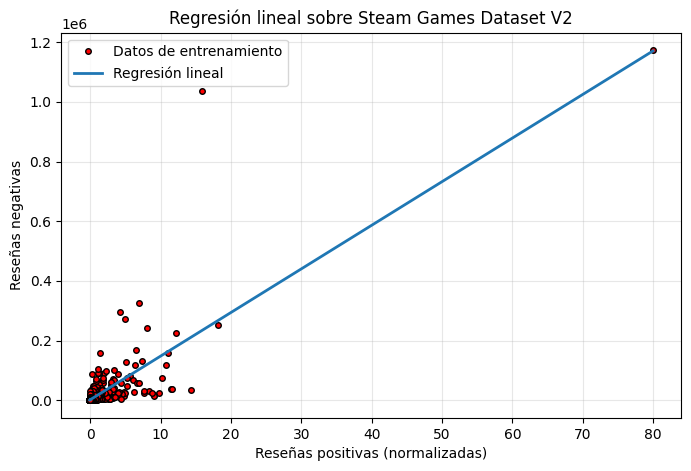

In [10]:
pyplot.figure(figsize=(8, 5))

pyplot.plot(x[:, 1], y, 'ro', ms=4, mec='k', label='Datos de entrenamiento')
pyplot.plot(x[:, 1], np.dot(x, theta), '-', linewidth=2, label='Regresión lineal')

pyplot.xlabel('Reseñas positivas (normalizadas)')
pyplot.ylabel('Reseñas negativas')
pyplot.title('Regresión lineal sobre Steam Games Dataset V2')
pyplot.legend()
pyplot.grid(True, alpha=0.3)

## Convergencia del costo

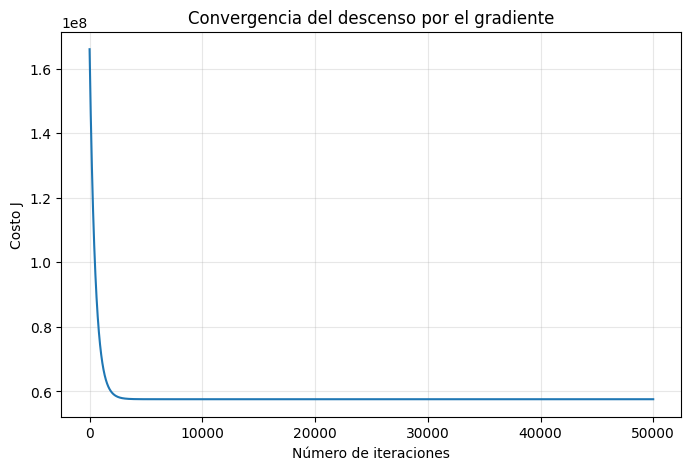

In [11]:
pyplot.figure(figsize=(8, 5))
pyplot.plot(np.arange(len(J_history)), J_history)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del descenso por el gradiente')
pyplot.grid(True, alpha=0.3)

## Superficie y contorno de la función de costo

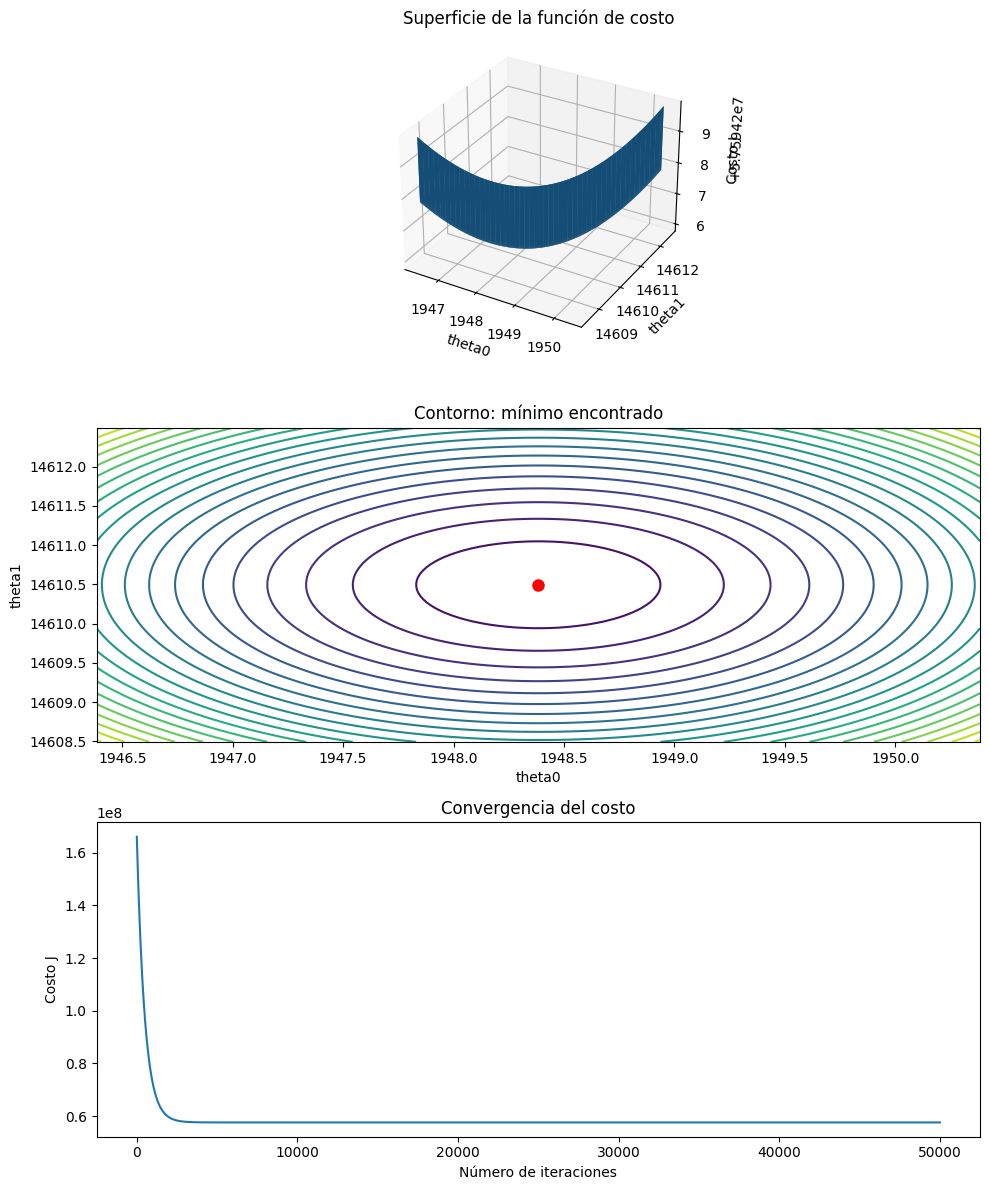

In [12]:
# Cuadrícula sobre la que se calcula J
theta0_vals = np.linspace(theta[0] - 2, theta[0] + 2, 100)
theta1_vals = np.linspace(theta[1] - 2, theta[1] + 2, 100)

# Inicializar J_vals
J_vals = np.zeros((theta0_vals.shape[0], theta1_vals.shape[0]))

# Calcular el costo para cada combinación de theta0 y theta1
for i, theta0 in enumerate(theta0_vals):
    for j, theta1 in enumerate(theta1_vals):
        J_vals[i, j] = calcularCosto(x, y, np.array([theta0, theta1]))

# Transponer para la representación gráfica
J_vals = J_vals.T

# Crear las gráficas
fig = pyplot.figure(figsize=(10, 12))

# Superficie 3D
ax = fig.add_subplot(311, projection='3d')
ax.plot_surface(theta0_vals, theta1_vals, J_vals)
ax.set_xlabel('theta0')
ax.set_ylabel('theta1')
ax.set_zlabel('Costo J')
ax.set_title('Superficie de la función de costo')

# Contorno
ax2 = pyplot.subplot(312)
pyplot.contour(theta0_vals, theta1_vals, J_vals, levels=20)
pyplot.xlabel('theta0')
pyplot.ylabel('theta1')
pyplot.plot(theta[0], theta[1], 'ro', ms=8)
pyplot.title('Contorno: mínimo encontrado')

# Convergencia
ax3 = pyplot.subplot(313)
pyplot.plot(np.arange(len(J_history)), J_history)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo')

pyplot.tight_layout()

## Interpretación

- `positive` representa la cantidad de reseñas positivas de cada juego.
- `negative` representa la cantidad de reseñas negativas.
- **Softmax y argmax no se utilizan en este laboratorio**, porque este ejercicio corresponde a **regresión lineal**, no a clasificación multiclase.
- El descenso por el gradiente busca los valores de `theta0` y `theta1` que minimizan la función de costo.
- La gráfica final permite observar qué tan bien una recta representa la relación entre ambas variables.

### Archivo de datos necesario

Descarga de Kaggle el archivo:

`extended_steam_games.csv`

y colócalo en la misma carpeta donde ejecutes este notebook.